In [ ]:
import scanpy as sc
import squidpy as sq
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
import anndata as ad
import dill
import h5py
import os
from typing import Dict, List, Tuple, Optional, Union
import json
import gc
from scipy import sparse
import cv2

In [ ]:
from skimage import segmentation, draw, io
from skimage.filters import gaussian, sobel
from skimage.color import rgb2gray
from skimage.segmentation import slic, mark_boundaries
from skimage.util import img_as_float
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import MinMaxScaler
from scipy import ndimage as ndi
from matplotlib.colors import ListedColormap, to_rgb
from skimage.draw import disk
import skimage
from scipy import ndimage as ndi

In [ ]:
%cd '/auto/brno2/home/luciakostialova/Thesis/src'

import importlib
import setup
import plot_clusters
import clustering
import image_segmentation
import ssgsea

importlib.reload(setup)
importlib.reload(plot_clusters)
importlib.reload(clustering)
importlib.reload(image_segmentation)

In [ ]:
%cd ..

In [ ]:
clustering.show_results('gene_sets_corr_slic_clustering/s0_output', 'gene_sets_corr_slic_clustering/s0_output/plots')

In [3]:
BASE_PATH = Path('/auto/brno2/home/luciakostialova/Master_thesis/10xVisium/BRCA1/')
data = ad.read_h5ad('BRCA_preprocessed.h5ad')
library_id='Visium_Human_Breast_Cancer'
data

AnnData object with n_obs × n_vars = 4847 × 24387
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts_umi', 'log1p_total_counts_umi', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'tissue_status', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts_genes', 'log1p_total_counts_genes', 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg', 'log1p', 'pca', 'spatial'
    obsm: 'X_pca', 'spatial'
    varm: 'PCs'
    layers: 'log1p', 'log1p_norm'

# check the distances

In [57]:
results_adata_path = Path('gene_expr_corr_slic_clustering/')
dirs = list(results_adata_path.glob('*'))
for d in dirs:
    inp = str(d)
    out = str(d)+'/plots'
    clustering.show

gene_expr_corr_slic_clustering/s2_output/plots
gene_expr_corr_slic_clustering/s8_output/plots
gene_expr_corr_slic_clustering/s0.5_output/plots
gene_expr_corr_slic_clustering/s4_output/plots
gene_expr_corr_slic_clustering/s0_output/plots
gene_expr_corr_slic_clustering/s6_output/plots
gene_expr_corr_slic_clustering/s10_output/plots
gene_expr_corr_slic_clustering/s1_output/plots


In [51]:
pwd

'/auto/brno2/home/luciakostialova/Thesis'

In [22]:
logdata = data.X.toarray().flatten()
pca = data.varm['PCs'].flatten()
pcadist = pdist(data.obsm['X_pca'], metric='correlation')
logdist = pdist(data.X.toarray(), metric='correlation')

In [31]:
data.layers['log1p_norm'].shape

(4847, 24387)

In [33]:
normdata = data.layers['log1p_norm'].toarray().flatten()
normdist = pdist(data.layers['log1p_norm'].toarray(), metric='correlation')

In [35]:
pcadisteu = pdist(data.obsm['X_pca'], metric='euclidean')
logdisteu = pdist(data.X.toarray(), metric='euclidean')
normdisteu = pdist(data.layers['log1p_norm'].toarray(), metric='euclidean')

In [46]:
pcanorm = sc.pp.pca(data.layers['log1p_norm'])
pcanormdist = pdist(pcanorm, metric='correlation')
pcanormdisteu = pdist(pcanorm, metric='euclidean')

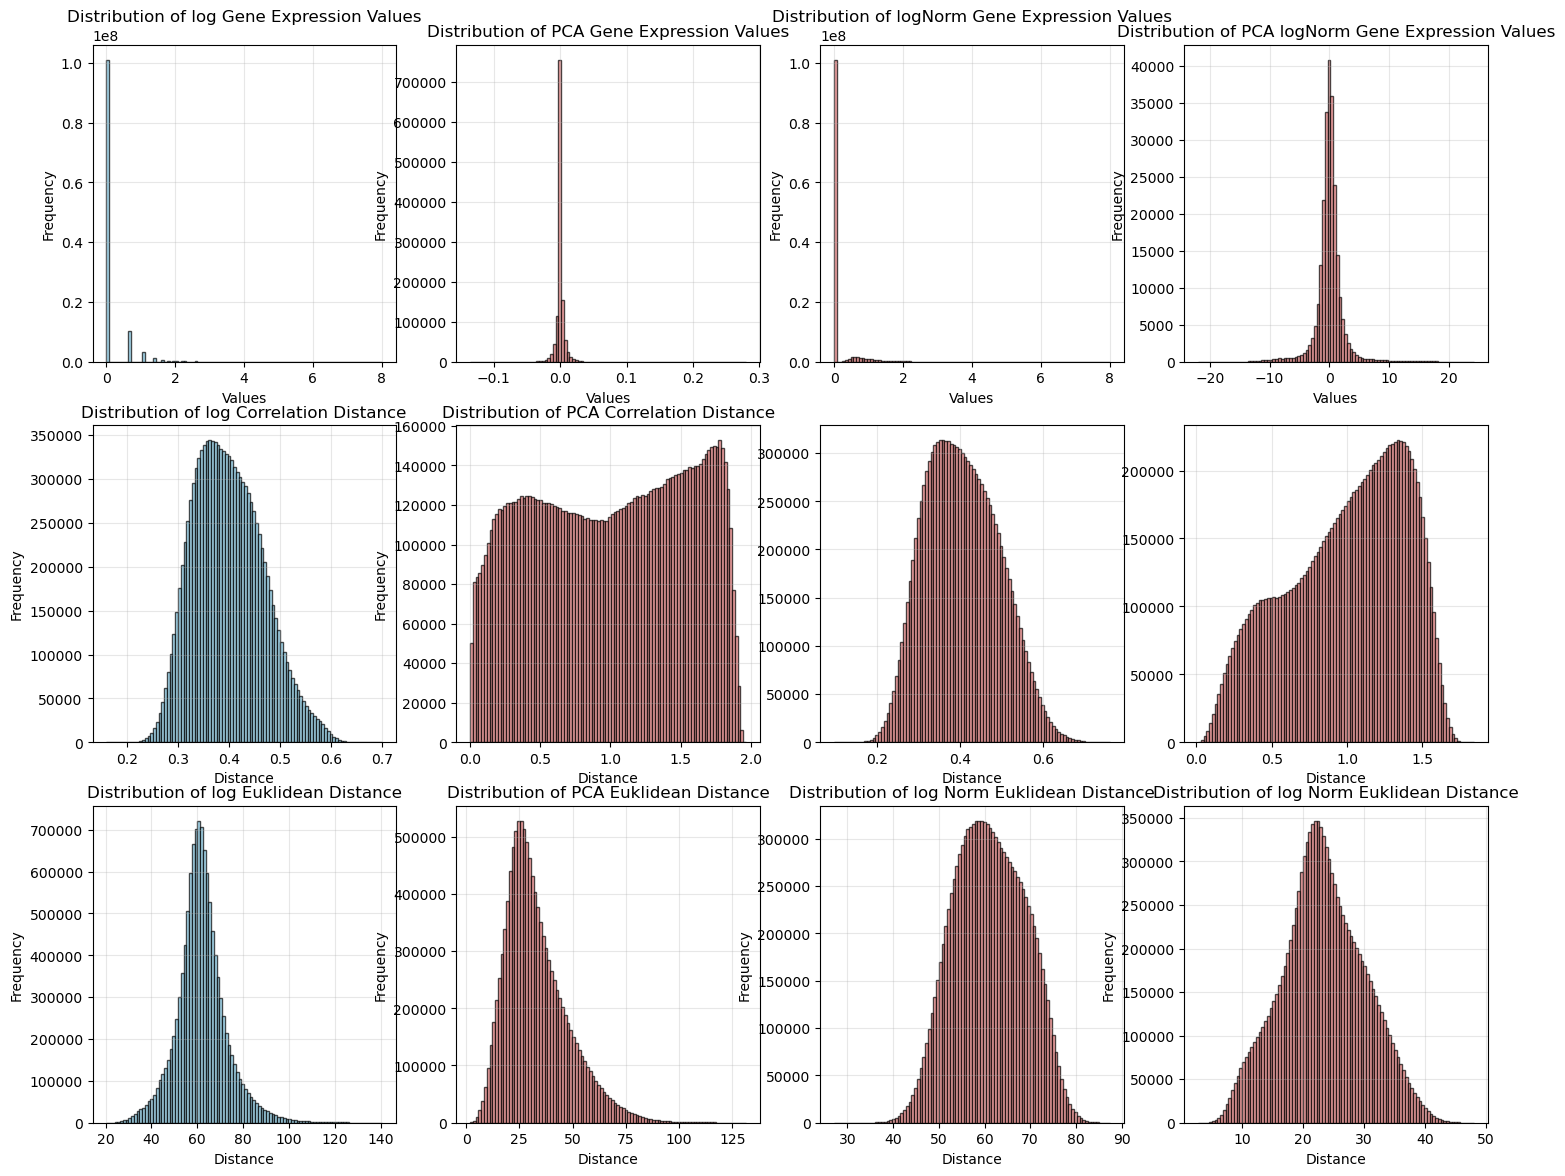

In [47]:
fig, ax = plt.subplots(3,4, figsize=(18, 14))

ax[0,0].hist(logdata, bins=100, alpha=0.7, color='skyblue', edgecolor='black')
ax[0,0].set_xlabel('Values')
ax[0,0].set_ylabel('Frequency')
ax[0,0].set_title('Distribution of log Gene Expression Values')
ax[0,0].grid(True, alpha=0.3)

ax[0,1].hist(pca, bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[0,1].set_xlabel('Values')
ax[0,1].set_ylabel('Frequency')
ax[0,1].set_title('Distribution of PCA Gene Expression Values')
ax[0,1].grid(True, alpha=0.3)

ax[0,2].hist(normdata, bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[0,2].set_xlabel('Values')
ax[0,2].set_ylabel('Frequency')
ax[0,2].set_title('Distribution of logNorm Gene Expression Values')
ax[0,2].grid(True, alpha=0.3)

ax[0,3].hist(pcanorm.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[0,3].set_xlabel('Values')
ax[0,3].set_ylabel('Frequency')
ax[0,3].set_title('Distribution of PCA logNorm Gene Expression Values')
ax[0,3].grid(True, alpha=0.3)

ax[1,0].hist(logdist.flatten(), bins=100, alpha=0.7, color='skyblue', edgecolor='black')
ax[1,0].set_xlabel('Distance')
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_title('Distribution of log Correlation Distance')
ax[1,0].grid(True, alpha=0.3)

ax[1,1].hist(pcadist.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[1,1].set_xlabel('Distance')
ax[1,1].set_ylabel('Frequency')
ax[1,1].set_title('Distribution of PCA Correlation Distance')
ax[1,1].grid(True, alpha=0.3)

ax[1,2].hist(normdist.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[1,2].set_xlabel('Distance')
ax[1,2].set_title('Distribution of log Norm Correlation Distance')
ax[1,2].set_title(f'')
ax[1,2].grid(True, alpha=0.3)

ax[1,3].hist(pcanormdist.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[1,3].set_xlabel('Distance')
ax[1,3].set_title('Distribution of log Norm Correlation Distance')
ax[1,3].set_title(f'')
ax[1,3].grid(True, alpha=0.3)

ax[2,0].hist(logdisteu.flatten(), bins=100, alpha=0.7, color='skyblue', edgecolor='black')
ax[2,0].set_xlabel('Distance')
ax[2,0].set_ylabel('Frequency')
ax[2,0].set_title('Distribution of log Euklidean Distance')
ax[2,0].grid(True, alpha=0.3)

ax[2,1].hist(pcadisteu.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[2,1].set_xlabel('Distance')
ax[2,1].set_ylabel('Frequency')
ax[2,1].set_title('Distribution of PCA Euklidean Distance')
ax[2,1].grid(True, alpha=0.3)

ax[2,2].hist(normdisteu.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[2,2].set_xlabel('Distance')
ax[2,2].set_ylabel('Frequency')
ax[2,2].set_title('Distribution of log Norm Euklidean Distance')
ax[2,2].grid(True, alpha=0.3)

ax[2,3].hist(pcanormdisteu.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
ax[2,3].set_xlabel('Distance')
ax[2,3].set_ylabel('Frequency')
ax[2,3].set_title('Distribution of log Norm Euklidean Distance')
ax[2,3].grid(True, alpha=0.3)

In [4]:
def plot_statistics(adata, library_id):
    ''' Plots gene expression values, gene expression correlation values for each spot, the unscaled correlation distance and unscaled segmentation distance. '''
    
    sigma = adata.uns['spatial'][library_id]['segmentation']['sigma']
    geneexpr_corr = adata.obsp['geneexpr_correlation']
    geneexpr_dist = adata.obsp['geneexpr_dist']
    segmentation_dist = adata.obsp['segmentation_dist']
    
    print(f'Minimum and maximum segmentation distances (sigma={sigma}): min = {np.min(segmentation_dist.flatten())} max = {np.max(segmentation_dist.flatten())}')
    print(f'Minimum and maximum gene expression values: min = {np.min(adata.X.toarray().flatten())} max = {np.max(adata.X.toarray().flatten())}')
    print(f'Minimum and maximum gene expression correlation values: min = {np.min(geneexpr_corr.flatten())} max = {np.max(geneexpr_corr.flatten())}')
    print(f'Minimum and maximum gene expression correlation distance values: min = {np.min(geneexpr_dist.flatten())} max = {np.max(geneexpr_dist.flatten())}')
    
    fig, ax = plt.subplots(2,2, figsize=(15, 10))
    
    ax[0,0].hist(adata.X.toarray().flatten(), bins=100, alpha=0.7, color='skyblue', edgecolor='black')
    ax[0,0].set_xlabel('Values')
    ax[0,0].set_ylabel('Frequency')
    ax[0,0].set_title('Distribution of Gene Expression Values')
    ax[0,0].grid(True, alpha=0.3)

    mask = np.triu(np.ones_like(geneexpr_corr, dtype=bool), k=1)
    correlation_values = geneexpr_corr[mask].flatten()
    
    ax[0,1].hist(correlation_values.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
    ax[0,1].set_xlabel('Pearson Correlation Coefficient')
    ax[0,1].set_ylabel('Frequency')
    ax[0,1].set_title('Distribution of Gene Expression Correlation')
    ax[0,1].grid(True, alpha=0.3)
    
    ax[1,0].hist(geneexpr_dist.flatten(), bins=100, alpha=0.7, color='skyblue', edgecolor='black')
    ax[1,0].set_xlabel('Distance')
    ax[1,0].set_ylabel('Frequency')
    ax[1,0].set_title('Distribution of Gene Expression Correlation Distance')
    ax[1,0].grid(True, alpha=0.3)
    
    ax[1,1].hist(segmentation_dist.flatten(), bins=100, alpha=0.7, color='lightcoral', edgecolor='black')
    ax[1,1].set_xlabel('Distance')
    ax[1,1].set_ylabel('Frequency')
    ax[1,1].set_title(f'Distribution of Segmentation Distance Matrix, sigma={sigma}')
    ax[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
